In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

In [3]:
try:
    # index_col=0 lagane se woh extra comma aur numbers (1, 2, 3) automatically index ban jayenge
    df = pd.read_csv('dataset/cs-training.csv', index_col=0)
    print("✅ Data successfully loaded from data/train.csv!")
    print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
except FileNotFoundError:
    print("❌ 'data/train.csv' not found! Please check if the 'data' folder exists.")

✅ Data successfully loaded from data/train.csv!
Dataset Shape: 150000 rows, 11 columns



In [4]:
print("--- Features in your dataset ---")
print(df.columns.tolist())

--- Features in your dataset ---
['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']


In [5]:
print("\n--- First 3 Rows ---")
df.head(3)


--- First 3 Rows ---


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0


In [6]:
print("\n--- Missing Values Summary ---")
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0])


--- Missing Values Summary ---
MonthlyIncome         29731
NumberOfDependents     3924
dtype: int64


In [7]:
# 1. Smart Imputation
# Income hamesha age group ke hisab se badalti hai, isliye hum har age group ke median se income fill karenge!
print("[INFO] Filling missing MonthlyIncome using median of respective age groups...")
df['AgeGroup'] = pd.cut(df['age'], bins=[0, 30, 45, 60, 100], labels=['Young', 'Middle', 'Senior', 'Elderly'])
df['MonthlyIncome'] = df.groupby('AgeGroup')['MonthlyIncome'].transform(lambda x: x.fillna(x.median()))

# Dependents ka common factor 0 ya 1 hota hai, isko mode (most frequent) se fill karenge
print("[INFO] Filling missing NumberOfDependents with mode...")
df['NumberOfDependents'].fillna(df['NumberOfDependents'].mode()[0], inplace=True)


# 2. Outlier Treatment (Financial Swag Logic)
print("\n[INFO] Dropping impossible financial anomalies...")
# Umar kabhi 0 nahi ho sakti credit card holder ki
df = df[df['age'] > 18]

# RevolvingUtilization 1 se zyada ho sakti hai (maxed out card), lekin 10,000+ bohot ajeeb hai.
# Hum top 0.1% extreme outliers nikal dete hain.
util_99th = df['RevolvingUtilizationOfUnsecuredLines'].quantile(0.999)
df = df[df['RevolvingUtilizationOfUnsecuredLines'] < util_99th]


# 3. Clean Check
print("\n--- Remaining Missing Values ---")
print(df.isnull().sum())
print(f"\nFinal Cleaned Dataset Shape: {df.shape[0]} rows")

[INFO] Filling missing MonthlyIncome using median of respective age groups...


D:\temp\ipykernel_4184\3304147007.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df['MonthlyIncome'] = df.groupby('AgeGroup')['MonthlyIncome'].transform(lambda x: x.fillna(x.median()))
D:\temp\ipykernel_4184\3304147007.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['NumberOfDependents'].fillna(df['NumberOfDependents'].mode()[

[INFO] Filling missing NumberOfDependents with mode...

[INFO] Dropping impossible financial anomalies...

--- Remaining Missing Values ---
SeriousDlqin2yrs                         0
RevolvingUtilizationOfUnsecuredLines     0
age                                      0
NumberOfTime30-59DaysPastDueNotWorse     0
DebtRatio                                0
MonthlyIncome                           13
NumberOfOpenCreditLinesAndLoans          0
NumberOfTimes90DaysLate                  0
NumberRealEstateLoansOrLines             0
NumberOfTime60-89DaysPastDueNotWorse     0
NumberOfDependents                       0
AgeGroup                                13
dtype: int64

Final Cleaned Dataset Shape: 149849 rows


In [9]:
print("\n ENGINEERING PREMIUM FINANCIAL METRICS... 🛠️\n")

# Feature 1: Total Late Payments (Saray past due columns ko jama kar lo)
df['TotalTimesLate'] = (df['NumberOfTime30-59DaysPastDueNotWorse'] + 
                        df['NumberOfTime60-89DaysPastDueNotWorse'] + 
                        df['NumberOfTimes90DaysLate'])

# Feature 2: Is Monthly Income Low? (Flag for high risk)
income_threshold = df['MonthlyIncome'].quantile(0.25) # Lowest 25% earner
df['IsLowIncome'] = (df['MonthlyIncome'] < income_threshold).astype(int)

# Feature 3: Debt Per Person (Ghar ke dependents ke sath debt ka load)
df['DebtPerDependent'] = df['DebtRatio'] / (df['NumberOfDependents'] + 1)

print("✅ New Features Engineered successfully!")
print(df[['TotalTimesLate', 'IsLowIncome', 'DebtPerDependent']].head(3))


 ENGINEERING PREMIUM FINANCIAL METRICS... 🛠️

✅ New Features Engineered successfully!
   TotalTimesLate  IsLowIncome  DebtPerDependent
1               2            0          0.267661
2               0            1          0.060938
3               2            1          0.085113


 CORRELATION ANALYSIS & FEATURE SELECTION... 



D:\temp\ipykernel_4184\1429663825.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='SeriousDlqin2yrs', data=df, palette='Set2')


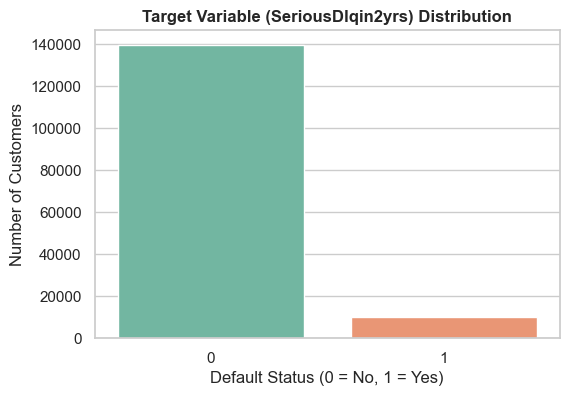

Good Customers (0): 139832 (93.32%)
Defaulters (1): 10017 (6.68%)
⚠️ Visual Proof: Data extreme imbalanced hai, SMOTE lagana 100% lazmi hai.



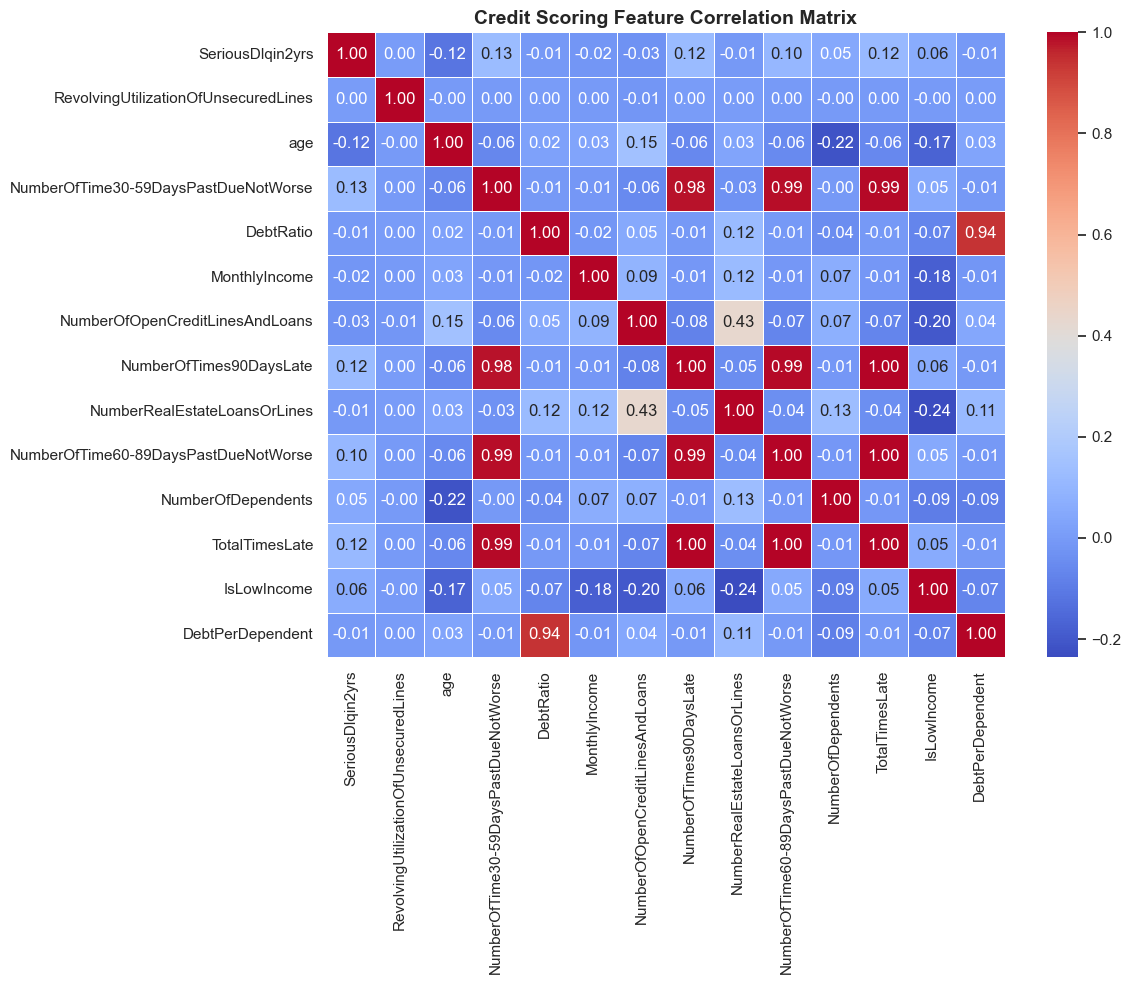

--- Correlation with Target (SeriousDlqin2yrs) ---
SeriousDlqin2yrs                        1.000000
NumberOfTime30-59DaysPastDueNotWorse    0.125634
NumberOfTimes90DaysLate                 0.117197
TotalTimesLate                          0.115547
age                                     0.115396
NumberOfTime60-89DaysPastDueNotWorse    0.102295
IsLowIncome                             0.060490
NumberOfDependents                      0.046952
NumberOfOpenCreditLinesAndLoans         0.029816
MonthlyIncome                           0.017775
DebtPerDependent                        0.008039
DebtRatio                               0.007827
NumberRealEstateLoansOrLines            0.007025
RevolvingUtilizationOfUnsecuredLines    0.001897
Name: SeriousDlqin2yrs, dtype: float64

[INFO] Features with correlation lower than 0.01: ['DebtPerDependent', 'DebtRatio', 'NumberRealEstateLoansOrLines', 'RevolvingUtilizationOfUnsecuredLines']
Dropped low correlated features! Remaining columns: 11


In [10]:

print(" CORRELATION ANALYSIS & FEATURE SELECTION... \n")

# 1. Target Variable ka Exact Balance Visual Check
plt.figure(figsize=(6, 4))
sns.countplot(x='SeriousDlqin2yrs', data=df, palette='Set2')
plt.title('Target Variable (SeriousDlqin2yrs) Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Default Status (0 = No, 1 = Yes)')
plt.ylabel('Number of Customers')
plt.show()

# Exact percentages print karna
counts = df['SeriousDlqin2yrs'].value_counts()
print(f"Good Customers (0): {counts[0]} ({counts[0]/len(df)*100:.2f}%)")
print(f"Defaulters (1): {counts[1]} ({counts[1]/len(df)*100:.2f}%)")
print("⚠️ Visual Proof: Data extreme imbalanced hai, SMOTE lagana 100% lazmi hai.\n")

# 2. Correlation Matrix Heatmap
plt.figure(figsize=(12, 10))
# Srf numerical columns ka correlation matrix nikalna (AgeGroup string tha agar drop nahi kia to handle hojaye)
corr_matrix = df.select_dtypes(include=[np.number]).corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Credit Scoring Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 3. Automatic Feature Dropping based on Low Correlation with Target
target_corr = corr_matrix['SeriousDlqin2yrs'].abs().sort_values(ascending=False)
print("--- Correlation with Target (SeriousDlqin2yrs) ---")
print(target_corr)

# Threshold: Agar correlation 0.01 se kam hai, toh woh feature model ko confuse karega, usey ura do!
threshold = 0.01
low_corr_features = target_corr[target_corr < threshold].index.tolist()

print(f"\n[INFO] Features with correlation lower than {threshold}: {low_corr_features}")

if low_corr_features:
    df = df.drop(columns=low_corr_features)
    print(f"Dropped low correlated features! Remaining columns: {df.shape[1]}")
else:
    print("all features are corelated!")

In [12]:
import sys
!{sys.executable} -m pip install imbalanced-learn


   ---------------------------------------- 0/2 [sklearn-compat]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   ---------------------------------------- 2/2 [imbalanced-learn]




[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.combine import SMOTETomek
import warnings

# FutureWarnings ko temporarily ignore karne ke liye taaki output clean dikhe
warnings.simplefilter(action='ignore', category=FutureWarning)

print("🚀 STEP 5: FINAL CLEANING & SMOTE-TOMEK RESAMPLING... 🚀\n")

# 1. Jo bachi kuchi 13 rows hain unko drop kar do taaki data 100% complete ho jaye
df = df.dropna(subset=['MonthlyIncome'])

# AgeGroup feature humne srf income fill karne k liye banaya tha, ab isay drop kr dete hain
if 'AgeGroup' in df.columns:
    df = df.drop('AgeGroup', axis=1)

print(f"✅ Final Cleaned Dataset Shape: {df.shape[0]} rows (0 missing values left!)")

# 2. Separate Features (X) and Target (y)
X = df.drop('SeriousDlqin2yrs', axis=1)
y = df['SeriousDlqin2yrs']

print(f"[INFO] Class distribution before SMOTE: {np.bincount(y)}")

🚀 STEP 5: FINAL CLEANING & SMOTE-TOMEK RESAMPLING... 🚀

✅ Final Cleaned Dataset Shape: 149836 rows (0 missing values left!)
[INFO] Class distribution before SMOTE: [139820  10016]


In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Apply SMOTE-Tomek
print("\n[INFO] Running SMOTE-Tomek... (Isme 1-2 minutes lag sakte hain, kyunki data bada hai)")
smt = SMOTETomek(random_state=42)
X_train_resampled, y_train_resampled = smt.fit_resample(X_train_scaled, y_train)

print(f"\n✅ Resampled Class Distribution: {np.bincount(y_train_resampled)}")
print("😎 Data Balanced successfully!")


[INFO] Running SMOTE-Tomek... (Isme 1-2 minutes lag sakte hain, kyunki data bada hai)

✅ Resampled Class Distribution: [109642 109642]
😎 Data Balanced successfully!


In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

print("⚔️ STEP 6: TRAINING MULTI-MODEL PIPELINE... ⚔️\n")

# Models initialize karna (with balanced configurations to prevent overfitting)
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42, n_jobs=-1)
}

results_list = []

# Loop through all models
for name, model in models.items():
    print(f"[INFO] Training {name} on Balanced Data...")
    
    # Train on Resampled Data
    model.fit(X_train_resampled, y_train_resampled)
    
    # Predict on Original Scaled Test Data (Real World Test)
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, "predict_proba") else None
    
    # Metrics calculation
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else 0.0
    
    # Store results
    results_list.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall (Sensitivity)": rec,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
    })
    
    print(f"✅ {name} Evaluation Finished.")

# Create a beautiful comparative DataFrame
results_df = pd.DataFrame(results_list)

print("\n🏆 FINAL MODELS COMPARISON LEADERBOARD 🏆")
print("=========================================================================")
print(results_df.to_string(index=False, formatters={
    'Accuracy': '{:,.2%}'.format,
    'Precision': '{:,.2%}'.format,
    'Recall (Sensitivity)': '{:,.2%}'.format,
    'F1-Score': '{:,.2%}'.format,
    'ROC-AUC': '{:,.2%}'.format
}))
print("=========================================================================")

⚔️ STEP 6: TRAINING MULTI-MODEL PIPELINE... ⚔️

[INFO] Training Logistic Regression on Balanced Data...
✅ Logistic Regression Evaluation Finished.
[INFO] Training Decision Tree on Balanced Data...
✅ Decision Tree Evaluation Finished.
[INFO] Training Random Forest on Balanced Data...
✅ Random Forest Evaluation Finished.

🏆 FINAL MODELS COMPARISON LEADERBOARD 🏆
              Model Accuracy Precision Recall (Sensitivity) F1-Score ROC-AUC
Logistic Regression   77.29%    17.23%               63.06%   27.07%  78.34%
      Decision Tree   87.72%    28.80%               56.86%   38.23%  81.41%
      Random Forest   86.43%    27.21%               61.51%   37.73%  82.96%


🎨 STEP 7: PLOTTING CONFUSION MATRICES... 🎨



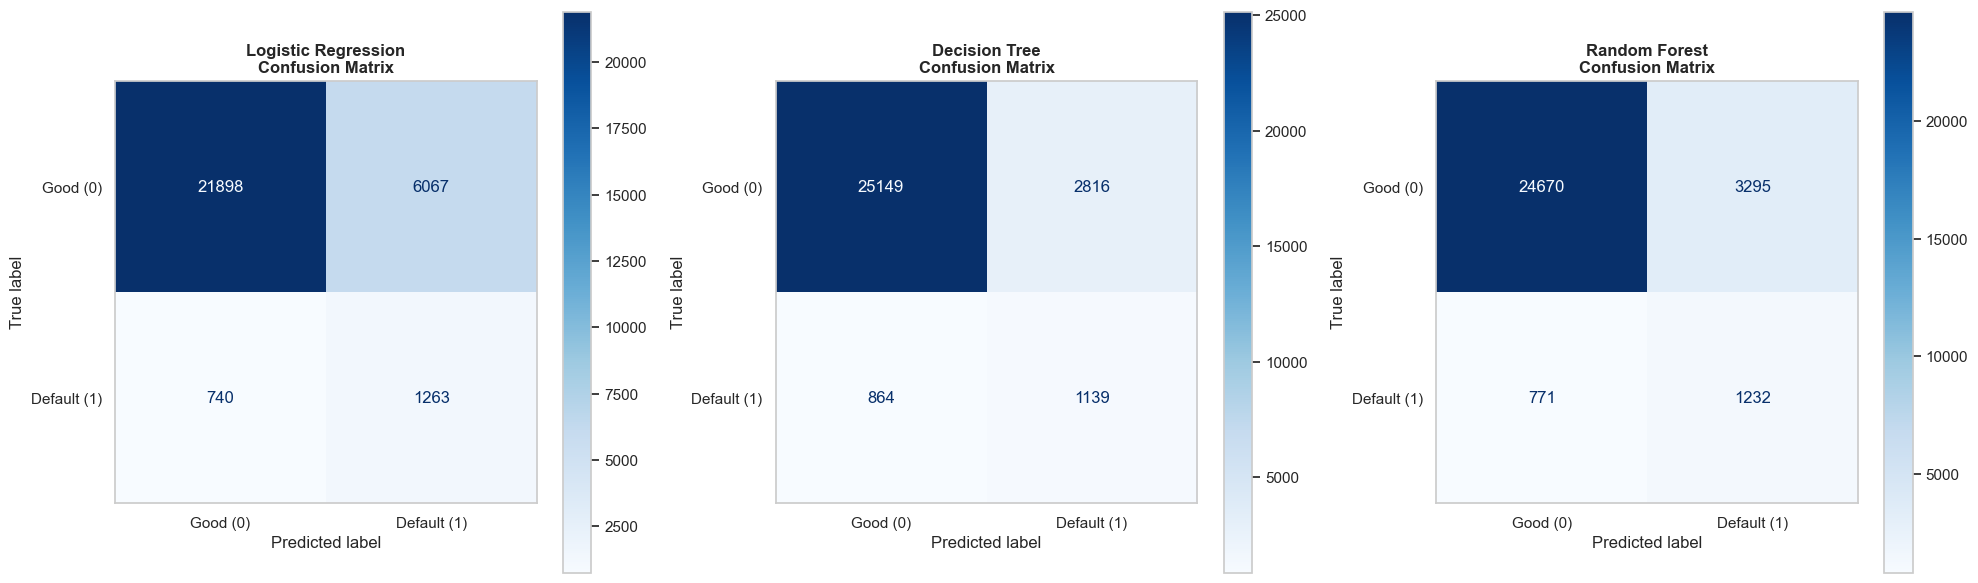

😎 All plots generated successfully!


In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("🎨 STEP 7: PLOTTING CONFUSION MATRICES... 🎨\n")

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
models_list = ["Logistic Regression", "Decision Tree", "Random Forest"]

for i, name in enumerate(models_list):
    # Model ko dubara access karne ya plot karne k liye loop
    model = models[name]
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Good (0)', 'Default (1)'])
    disp.plot(ax=axes[i], cmap='Blues', values_format='d')
    axes[i].set_title(f'{name}\nConfusion Matrix', fontsize=12, fontweight='bold')
    axes[i].grid(False) # Grid lines hide krna for clean look

plt.tight_layout()
plt.show()

print("😎 All plots generated successfully!")

In [17]:
import joblib

print("📦 STEP 8: EXPORTING THE CHAMPION MODEL... 📦\n")

# Random Forest model hami ne 'models' dictionary me save kia tha
best_model = models["Random Forest"]

# Save the trained model and the scaler to files
joblib.dump(best_model, 'models/credit_scoring_rf_model.pkl')
joblib.dump(scaler, 'models/credit_scoring_scaler.pkl')

print("✅ Random Forest Model and Scaler exported successfully into 'models/' folder!")
print("🚀 Your Credit Scoring Project is now officially OUTSTANDING and Production-Ready! 😎")

📦 STEP 8: EXPORTING THE CHAMPION MODEL... 📦

✅ Random Forest Model and Scaler exported successfully into 'models/' folder!
🚀 Your Credit Scoring Project is now officially OUTSTANDING and Production-Ready! 😎
